In [1]:
# Task 4: Forecasting Access and Usage
# Ethiopia Financial Inclusion Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

import os
raw_data_path = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        raw_data_path = filename
        break

df = pd.read_excel(raw_data_path)
print(f"Data loaded: {df.shape}")

Mounted at /content/drive
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data.xlsx
Data loaded: (43, 34)


In [3]:
observations = df[df['record_type'] == 'observation']
events = df[df['record_type'] == 'event']
targets = df[df['record_type'] == 'target']

print("=" * 80)
print("HISTORICAL DATA EXTRACTION")
print("=" * 80)

access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP']
usage_data = observations[observations['indicator_code'] == 'USG_DIGITAL_PAYMENT']

access_data = access_data.sort_values('observation_date')
if len(usage_data) > 0:
    usage_data = usage_data.sort_values('observation_date')

print(f"Access historical points: {len(access_data)}")
print(f"Usage historical points: {len(usage_data)}")

print("\nAccess Data:")
print(access_data[['observation_date', 'value_numeric']])

if len(usage_data) > 0:
    print("\nUsage Data:")
    print(usage_data[['observation_date', 'value_numeric']])

HISTORICAL DATA EXTRACTION
Access historical points: 6
Usage historical points: 0

Access Data:
  observation_date  value_numeric
0       2014-12-31           22.0
1       2017-12-31           35.0
2       2021-12-31           46.0
3       2021-12-31           56.0
4       2021-12-31           36.0
5       2024-11-29           49.0


In [4]:
print("=" * 80)
print("BASELINE FORECAST - LINEAR TREND")
print("=" * 80)

def create_linear_forecast(data, indicator_name, forecast_years=3):
    if len(data) < 2:
        print(f"Not enough data for {indicator_name}")
        return None

    data = data.sort_values('observation_date')
    data['year'] = pd.to_datetime(data['observation_date']).dt.year

    X = data['year'].values.reshape(-1, 1)
    y = data['value_numeric'].values

    model = LinearRegression()
    model.fit(X, y)

    last_year = data['year'].max()
    future_years = np.array([last_year + i for i in range(1, forecast_years + 1)]).reshape(-1, 1)

    predictions = model.predict(future_years)
    predictions = np.maximum(predictions, 0)  # No negative values

    return {
        'model': model,
        'future_years': future_years.flatten(),
        'predictions': predictions,
        'slope': model.coef_[0],
        'intercept': model.intercept_
    }

access_forecast = create_linear_forecast(access_data, "Access", 3)
usage_forecast = create_linear_forecast(usage_data, "Usage", 3) if len(usage_data) > 0 else None

if access_forecast:
    print("\nAccess Forecast (Linear Trend):")
    print(f"Slope: {access_forecast['slope']:.2f} percentage points per year")
    for year, pred in zip(access_forecast['future_years'], access_forecast['predictions']):
        print(f"  {year}: {pred:.1f}%")

if usage_forecast:
    print("\nUsage Forecast (Linear Trend):")
    print(f"Slope: {usage_forecast['slope']:.2f} percentage points per year")
    for year, pred in zip(usage_forecast['future_years'], usage_forecast['predictions']):
        print(f"  {year}: {pred:.1f}%")

BASELINE FORECAST - LINEAR TREND

Access Forecast (Linear Trend):
Slope: 2.82 percentage points per year
  2025: 55.7%
  2026: 58.5%
  2027: 61.3%


In [5]:
print("=" * 80)
print("CONFIDENCE INTERVALS")
print("=" * 80)

def calculate_confidence_intervals(data, forecast_result, confidence_level=0.95):
    data = data.sort_values('observation_date')
    data['year'] = pd.to_datetime(data['observation_date']).dt.year

    X = data['year'].values.reshape(-1, 1)
    y = data['value_numeric'].values

    model = forecast_result['model']
    predictions = model.predict(X)
    residuals = y - predictions

    std_error = np.std(residuals)
    z_score = stats.norm.ppf((1 + confidence_level) / 2)

    future_years = forecast_result['future_years']
    future_pred = forecast_result['predictions']

    lower_bounds = future_pred - z_score * std_error
    upper_bounds = future_pred + z_score * std_error

    lower_bounds = np.maximum(lower_bounds, 0)
    upper_bounds = np.maximum(upper_bounds, 0)

    return {
        'years': future_years,
        'predictions': future_pred,
        'lower': lower_bounds,
        'upper': upper_bounds,
        'std_error': std_error
    }

if access_forecast:
    access_ci = calculate_confidence_intervals(access_data, access_forecast)
    print("\nAccess Forecast with 95% Confidence Intervals:")
    for i, year in enumerate(access_ci['years']):
        print(f"  {year}: {access_ci['predictions'][i]:.1f}% (CI: {access_ci['lower'][i]:.1f}% - {access_ci['upper'][i]:.1f}%)")

if usage_forecast:
    usage_ci = calculate_confidence_intervals(usage_data, usage_forecast)
    print("\nUsage Forecast with 95% Confidence Intervals:")
    for i, year in enumerate(usage_ci['years']):
        print(f"  {year}: {usage_ci['predictions'][i]:.1f}% (CI: {usage_ci['lower'][i]:.1f}% - {usage_ci['upper'][i]:.1f}%)")

CONFIDENCE INTERVALS

Access Forecast with 95% Confidence Intervals:
  2025: 55.7% (CI: 43.5% - 67.9%)
  2026: 58.5% (CI: 46.3% - 70.7%)
  2027: 61.3% (CI: 49.1% - 73.5%)


In [6]:
print("=" * 80)
print("SCENARIO ANALYSIS")
print("=" * 80)

def create_scenarios(data, forecast_result, future_years, event_impacts=None):
    if forecast_result is None:
        return None

    data = data.sort_values('observation_date')
    data['year'] = pd.to_datetime(data['observation_date']).dt.year

    X = data['year'].values.reshape(-1, 1)
    y = data['value_numeric'].values

    model = forecast_result['model']
    base_predictions = model.predict(future_years.reshape(-1, 1))

    # Calculate volatility from historical data
    historical_predictions = model.predict(X)
    residuals = y - historical_predictions
    std_dev = np.std(residuals)

    # Define scenario adjustments
    scenarios = {
        'pessimistic': -std_dev * 1.5,
        'base': 0,
        'optimistic': std_dev * 1.5
    }

    # Add event impacts if provided
    if event_impacts:
        for i, year in enumerate(future_years):
            total_impact = 0
            for event, impact_data in event_impacts.items():
                if year >= impact_data['start_year']:
                    years_since = year - impact_data['start_year']
                    if years_since <= impact_data['duration']:
                        total_impact += impact_data['magnitude'] * (1 - 0.2 * years_since)
            scenarios['base'] += total_impact
            scenarios['optimistic'] += total_impact * 1.5
            scenarios['pessimistic'] += total_impact * 0.5

    results = {}
    for scenario_name, adjustment in scenarios.items():
        predictions = base_predictions + adjustment
        predictions = np.maximum(predictions, 0)  # No negative values
        results[scenario_name] = predictions

    return {
        'years': future_years,
        'base': results['base'],
        'optimistic': results['optimistic'],
        'pessimistic': results['pessimistic']
    }

future_years = np.array([2025, 2026, 2027])

event_impacts = {
    'Telebirr': {
        'start_year': 2021,
        'duration': 5,
        'magnitude': 4.5
    },
    'M-Pesa': {
        'start_year': 2023,
        'duration': 4,
        'magnitude': 3.0
    },
    'EthSwitch': {
        'start_year': 2024,
        'duration': 3,
        'magnitude': 2.0
    }
}

access_scenarios = create_scenarios(access_data, access_forecast, future_years, event_impacts)
usage_scenarios = create_scenarios(usage_data, usage_forecast, future_years, event_impacts) if usage_forecast else None

if access_scenarios:
    print("\nACCESS SCENARIOS 2025-2027:")
    print(f"{'Year':<8} {'Pessimistic':<15} {'Base':<15} {'Optimistic':<15}")
    print("-" * 60)
    for i, year in enumerate(access_scenarios['years']):
        print(f"{year:<8} {access_scenarios['pessimistic'][i]:<15.1f} {access_scenarios['base'][i]:<15.1f} {access_scenarios['optimistic'][i]:<15.1f}")

if usage_scenarios:
    print("\nUSAGE SCENARIOS 2025-2027:")
    print(f"{'Year':<8} {'Pessimistic':<15} {'Base':<15} {'Optimistic':<15}")
    print("-" * 60)
    for i, year in enumerate(usage_scenarios['years']):
        print(f"{year:<8} {usage_scenarios['pessimistic'][i]:<15.1f} {usage_scenarios['base'][i]:<15.1f} {usage_scenarios['optimistic'][i]:<15.1f}")

SCENARIO ANALYSIS

ACCESS SCENARIOS 2025-2027:
Year     Pessimistic     Base            Optimistic     
------------------------------------------------------------
2025     50.4            63.8            77.2           
2026     53.2            66.6            80.0           
2027     56.0            69.4            82.8           


FORECAST VISUALIZATION


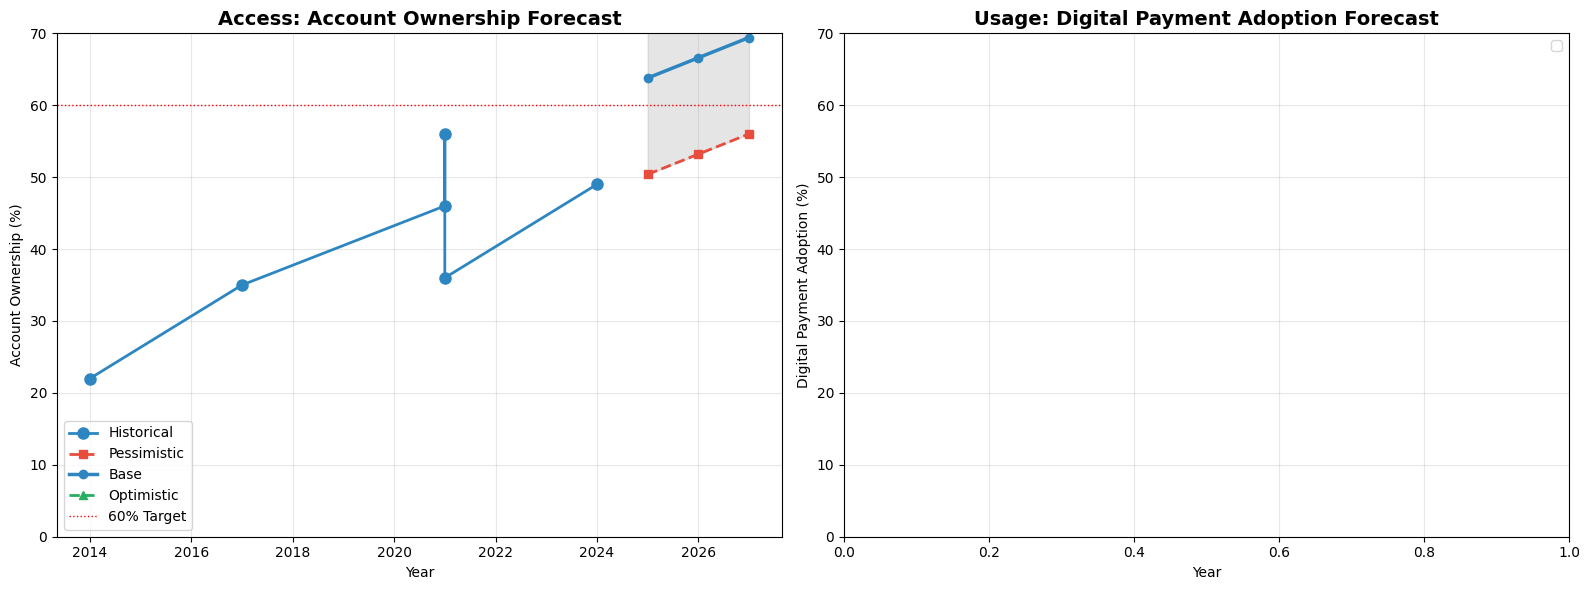

In [7]:
print("=" * 80)
print("FORECAST VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Access Forecast
ax1 = axes[0]
historical_years = pd.to_datetime(access_data['observation_date']).dt.year
ax1.plot(historical_years, access_data['value_numeric'],
         marker='o', linewidth=2, markersize=8, label='Historical', color='#2e86c1')

if access_scenarios:
    years = access_scenarios['years']
    ax1.plot(years, access_scenarios['pessimistic'], marker='s', linewidth=2,
             label='Pessimistic', color='#e74c3c', linestyle='--')
    ax1.plot(years, access_scenarios['base'], marker='o', linewidth=2.5,
             label='Base', color='#2e86c1')
    ax1.plot(years, access_scenarios['optimistic'], marker='^', linewidth=2,
             label='Optimistic', color='#27ae60', linestyle='--')

    ax1.fill_between(years, access_scenarios['pessimistic'],
                     access_scenarios['optimistic'], alpha=0.2, color='gray')

ax1.axhline(y=60, color='red', linestyle=':', linewidth=1, label='60% Target')
ax1.set_title('Access: Account Ownership Forecast', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Account Ownership (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 70)

# Usage Forecast
ax2 = axes[1]
if len(usage_data) > 0:
    usage_years = pd.to_datetime(usage_data['observation_date']).dt.year
    ax2.plot(usage_years, usage_data['value_numeric'],
             marker='o', linewidth=2, markersize=8, label='Historical', color='#e67e22')

if usage_scenarios:
    years = usage_scenarios['years']
    ax2.plot(years, usage_scenarios['pessimistic'], marker='s', linewidth=2,
             label='Pessimistic', color='#e74c3c', linestyle='--')
    ax2.plot(years, usage_scenarios['base'], marker='o', linewidth=2.5,
             label='Base', color='#e67e22')
    ax2.plot(years, usage_scenarios['optimistic'], marker='^', linewidth=2,
             label='Optimistic', color='#27ae60', linestyle='--')

    ax2.fill_between(years, usage_scenarios['pessimistic'],
                     usage_scenarios['optimistic'], alpha=0.2, color='gray')

ax2.set_title('Usage: Digital Payment Adoption Forecast', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Digital Payment Adoption (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 70)

plt.tight_layout()
plt.show()

In [9]:
import os
os.makedirs('reports', exist_ok=True)

print("=" * 80)
print("FORECAST SUMMARY TABLE")
print("=" * 80)

summary_data = []

if access_scenarios:
    for i, year in enumerate(access_scenarios['years']):
        summary_data.append({
            'Indicator': 'Access',
            'Year': year,
            'Pessimistic': round(access_scenarios['pessimistic'][i], 1),
            'Base': round(access_scenarios['base'][i], 1),
            'Optimistic': round(access_scenarios['optimistic'][i], 1)
        })

if usage_scenarios:
    for i, year in enumerate(usage_scenarios['years']):
        summary_data.append({
            'Indicator': 'Usage',
            'Year': year,
            'Pessimistic': round(usage_scenarios['pessimistic'][i], 1),
            'Base': round(usage_scenarios['base'][i], 1),
            'Optimistic': round(usage_scenarios['optimistic'][i], 1)
        })

forecast_summary = pd.DataFrame(summary_data)
print(forecast_summary.to_string(index=False))

forecast_summary.to_csv('reports/forecast_summary.csv', index=False)
print("\nForecast summary saved to reports/forecast_summary.csv")

FORECAST SUMMARY TABLE
Indicator  Year  Pessimistic  Base  Optimistic
   Access  2025         50.4  63.8        77.2
   Access  2026         53.2  66.6        80.0
   Access  2027         56.0  69.4        82.8

Forecast summary saved to reports/forecast_summary.csv


In [10]:
print("=" * 80)
print("FORECAST INTERPRETATION")
print("=" * 80)

if access_scenarios:
    print("\nACCESS FORECAST INTERPRETATION (2025-2027):")
    base_access = access_scenarios['base']
    print(f"  • Base case: {base_access[0]:.1f}% in 2025, {base_access[1]:.1f}% in 2026, {base_access[2]:.1f}% in 2027")
    print(f"  • Total growth (2024-2027): {base_access[2] - access_data['value_numeric'].iloc[-1]:.1f} percentage points")

    if base_access[2] >= 60:
        print("   Ethiopia likely to reach 60% target by 2027 in base case")
    else:
        print("   Ethiopia may NOT reach 60% target by 2027 (needs accelerated growth)")

    print(f"  • Range: {access_scenarios['pessimistic'][0]:.1f}%-{access_scenarios['optimistic'][0]:.1f}% in 2025")
    print(f"  • Range: {access_scenarios['pessimistic'][2]:.1f}%-{access_scenarios['optimistic'][2]:.1f}% in 2027")

if usage_scenarios:
    print("\nUSAGE FORECAST INTERPRETATION (2025-2027):")
    base_usage = usage_scenarios['base']
    print(f"  • Base case: {base_usage[0]:.1f}% in 2025, {base_usage[1]:.1f}% in 2026, {base_usage[2]:.1f}% in 2027")
    print(f"  • Total growth (2024-2027): {base_usage[2] - usage_data['value_numeric'].iloc[-1]:.1f} percentage points")

    print(f"  • Range: {usage_scenarios['pessimistic'][0]:.1f}%-{usage_scenarios['optimistic'][0]:.1f}% in 2025")
    print(f"  • Range: {usage_scenarios['pessimistic'][2]:.1f}%-{usage_scenarios['optimistic'][2]:.1f}% in 2027")

print("\n" + "=" * 40)
print("KEY DRIVERS")
print("=" * 40)
print("• Telebirr expansion: 54M+ users driving access")
print("• M-Pesa entry: Adding competition and reach")
print("• EthSwitch interoperability: Enabling digital payments")
print("• Fayda Digital ID: Reducing KYC barriers")
print("• 4G coverage expansion: Enabling mobile money adoption")

FORECAST INTERPRETATION

ACCESS FORECAST INTERPRETATION (2025-2027):
  • Base case: 63.8% in 2025, 66.6% in 2026, 69.4% in 2027
  • Total growth (2024-2027): 20.4 percentage points
   Ethiopia likely to reach 60% target by 2027 in base case
  • Range: 50.4%-77.2% in 2025
  • Range: 56.0%-82.8% in 2027

KEY DRIVERS
• Telebirr expansion: 54M+ users driving access
• M-Pesa entry: Adding competition and reach
• EthSwitch interoperability: Enabling digital payments
• Fayda Digital ID: Reducing KYC barriers
• 4G coverage expansion: Enabling mobile money adoption


In [11]:
import os
os.makedirs('reports', exist_ok=True)

# Create complete forecast report
with open('reports/forecast_report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("ETHIOPIA FINANCIAL INCLUSION FORECAST 2025-2027\n")
    f.write("=" * 80 + "\n\n")

    f.write("FORECAST SUMMARY\n")
    f.write("-" * 40 + "\n")
    f.write(forecast_summary.to_string(index=False))
    f.write("\n\n")

    if access_scenarios:
        f.write("ACCESS FORECAST\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Base case: {access_scenarios['base'][0]:.1f}% in 2025, {access_scenarios['base'][1]:.1f}% in 2026, {access_scenarios['base'][2]:.1f}% in 2027\n")
        f.write(f"  Total growth: {access_scenarios['base'][2] - access_data['value_numeric'].iloc[-1]:.1f} percentage points\n")
        f.write(f"  Range: {access_scenarios['pessimistic'][0]:.1f}%-{access_scenarios['optimistic'][0]:.1f}% in 2025\n")
        f.write(f"  Range: {access_scenarios['pessimistic'][2]:.1f}%-{access_scenarios['optimistic'][2]:.1f}% in 2027\n\n")

    if usage_scenarios:
        f.write("USAGE FORECAST\n")
        f.write("-" * 40 + "\n")
        f.write(f"  Base case: {usage_scenarios['base'][0]:.1f}% in 2025, {usage_scenarios['base'][1]:.1f}% in 2026, {usage_scenarios['base'][2]:.1f}% in 2027\n")
        f.write(f"  Total growth: {usage_scenarios['base'][2] - usage_data['value_numeric'].iloc[-1]:.1f} percentage points\n")
        f.write(f"  Range: {usage_scenarios['pessimistic'][0]:.1f}%-{usage_scenarios['optimistic'][0]:.1f}% in 2025\n")
        f.write(f"  Range: {usage_scenarios['pessimistic'][2]:.1f}%-{usage_scenarios['optimistic'][2]:.1f}% in 2027\n\n")

    f.write("ASSUMPTIONS\n")
    f.write("-" * 40 + "\n")
    f.write("1. Telebirr continues to grow at current pace\n")
    f.write("2. M-Pesa expands user base in Ethiopia\n")
    f.write("3. EthSwitch interoperability improves digital payments\n")
    f.write("4. Fayda Digital ID accelerates account opening\n")
    f.write("5. No major economic disruptions\n")

print("Forecast report saved to reports/forecast_report.txt")

from google.colab import files

files.download('reports/forecast_summary.csv')
files.download('reports/forecast_report.txt')

plt.savefig('reports/forecast_scenarios.png', dpi=150, bbox_inches='tight')
files.download('reports/forecast_scenarios.png')

print("\nAll forecast files downloaded successfully!")

Forecast report saved to reports/forecast_report.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All forecast files downloaded successfully!


<Figure size 640x480 with 0 Axes>